# 📊 Employee Attrition & Performance Analysis

## 🎯 Objective
The objective of this project is to analyze employee attrition and identify key factors influencing employees leaving the company.

## 📌 Problem Statement
High employee attrition leads to increased costs and reduced productivity. This project aims to find patterns and reasons behind employee turnover.

## 📂 Dataset
IBM HR Analytics Employee Attrition Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use default matplotlib style

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

## 📊 Dataset Overview

The dataset contains:
- Employee details (Age, Gender, Department)
- Job details (Role, Salary, Experience)
- Satisfaction metrics
- Attrition (Yes/No)

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 🧹 Data Cleaning & Preprocessing

We create a copy of dataset to avoid modifying original data.

In [5]:
df_copy = df.copy()
df_copy.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 🧪 Creating Missing Values (For Data Cleaning Demonstration)

Artificial missing values are introduced to demonstrate data cleaning techniques.

In [6]:
import numpy as np

# Create missing values
df_copy.loc[0:5, 'MonthlyIncome'] = np.nan
df_copy.loc[10:12, 'Age'] = np.nan

df_copy.isnull().sum()

Age                         3
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               6
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## 🧹 Handling Missing Values
Missing values are handled using forward fill method.

In [7]:
df_copy = df_copy.ffill()
df_copy.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               6
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df_copy.dtypes

Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
StockOptionLevel            

## 📊 KPI Summary
Key metrics are calculated to understand attrition.

In [9]:
total_employees = len(df_copy)
employees_left = df_copy[df_copy['Attrition'] == 'Yes'].shape[0]
attrition_rate = (employees_left / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12%


## 🔍 Attrition Analysis

In [10]:
df_copy['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
attrition_rate = (df_copy['Attrition'].value_counts()['Yes'] / len(df_copy)) * 100
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


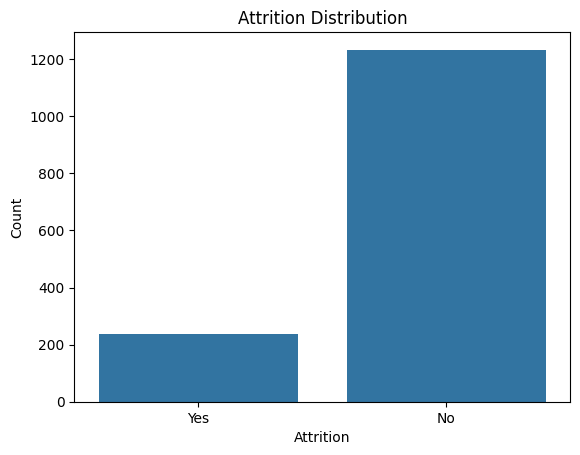

In [12]:
import seaborn as sns

sns.countplot(x='Attrition', data=df_copy)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

👉 Insight: Sales department shows higher attrition due to work pressure.

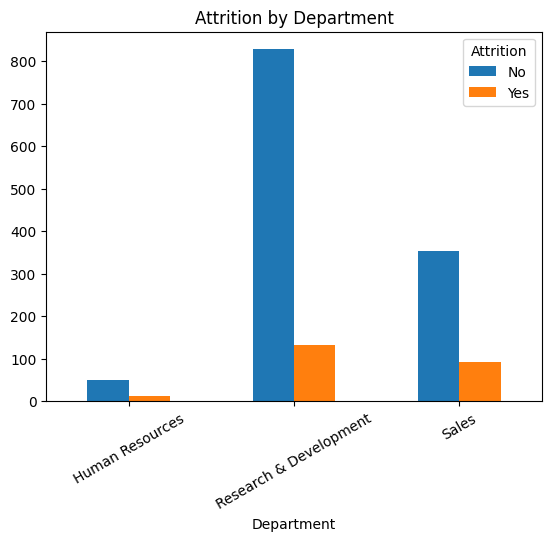

In [13]:
pd.crosstab(df_copy['Department'], df_copy['Attrition']).plot(kind='bar')
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

## 📊 Salary vs Attrition

This chart shows how salary impacts employee attrition.

C:\Users\Dell\AppData\Local\Temp\ipykernel_9032\2424607687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


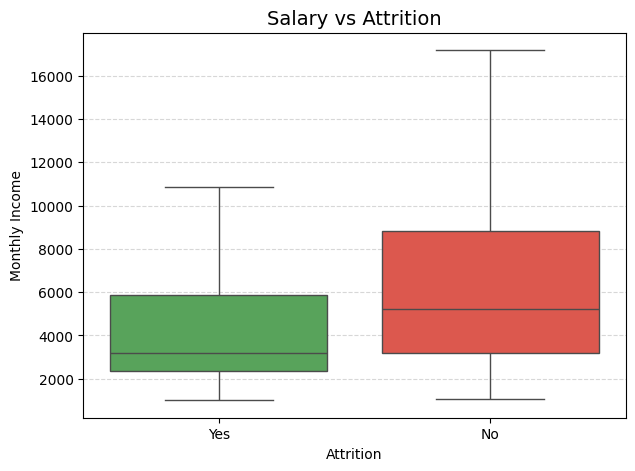

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_copy,
    palette=['#4CAF50', '#F44336'],
    showfliers=False   # removes extra dots (outliers)
)

plt.title("Salary vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

👉 Insight: Younger employees tend to leave more.

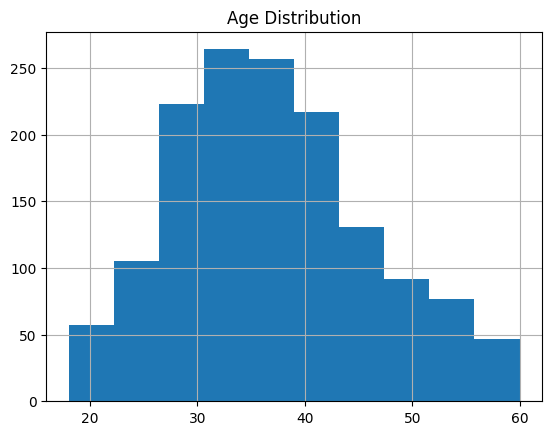

In [15]:
df_copy['Age'].hist()
plt.title("Age Distribution")
plt.show()

👉 Insight: Low satisfaction leads to higher attrition.

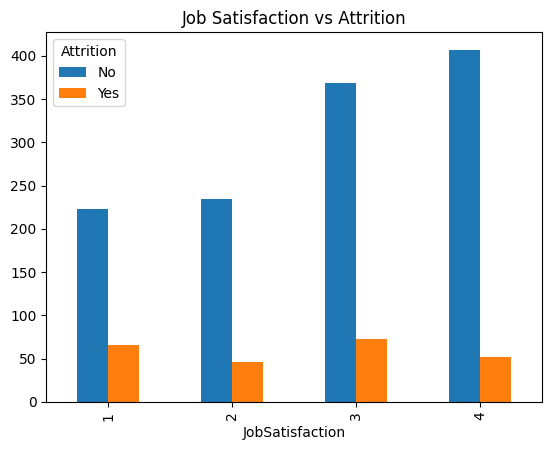

In [16]:
pd.crosstab(df_copy['JobSatisfaction'], df_copy['Attrition']).plot(kind='bar')
plt.title("Job Satisfaction vs Attrition")
plt.show()

👉 Insight: Poor work-life balance increases attrition.

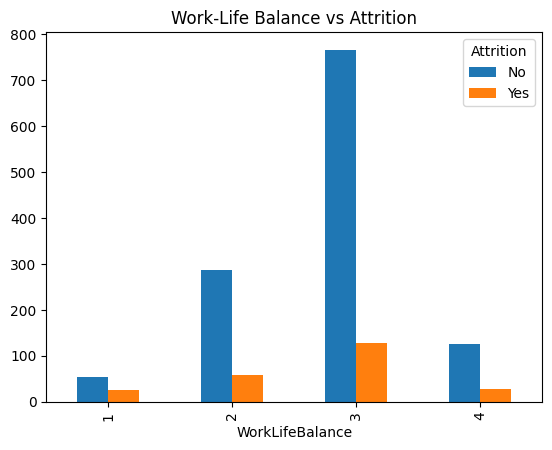

In [17]:
pd.crosstab(df_copy['WorkLifeBalance'], df_copy['Attrition']).plot(kind='bar')
plt.title("Work-Life Balance vs Attrition")
plt.show()

## 📊 Years at Company vs Attrition

This visualization shows the relationship between employee experience and attrition using a boxplot.

👉 Green = Employees who stayed  
👉 Red = Employees who left

## 🔍 Insight

Employees with fewer years at the company are more likely to leave.  
Employees who stay longer show lower attrition, indicating better retention over time.

C:\Users\Dell\AppData\Local\Temp\ipykernel_9032\1130194664.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


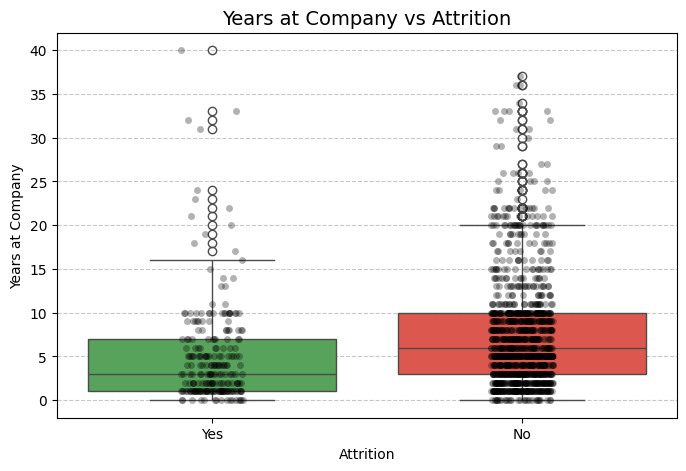

In [18]:


plt.figure(figsize=(8,5))

# Boxplot
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df_copy,
    palette=['#4CAF50', '#F44336']
)

# Add data points
sns.stripplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df_copy,
    color='black',
    alpha=0.3
)

plt.title("Years at Company vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [19]:
# Example test
test_total = 100
test_left = 10

test_rate = (test_left / test_total) * 100
print("Test Attrition Rate:", test_rate)

Test Attrition Rate: 10.0


## 🔥 Correlation Heatmap Insight

- Monthly Income and Job Level have strong positive correlation  
- Total Working Years is related to Years at Company  
- Age is positively related to experience  
- Job Satisfaction and Work-Life Balance have weak correlation  
- Performance Rating shows very low correlation  

👉 Conclusion: Salary mainly depends on experience and job level.

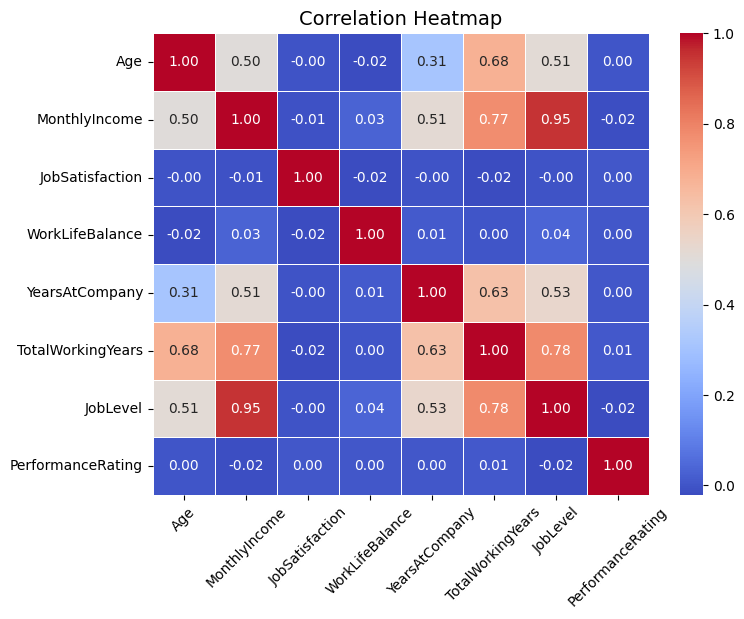

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Important columns
important_cols = [
    'Age', 'MonthlyIncome', 'JobSatisfaction',
    'WorkLifeBalance', 'YearsAtCompany',
    'TotalWorkingYears', 'JobLevel',
    'PerformanceRating'
]

# Correlation
corr = df_copy[important_cols].corr()

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

## 🧪 Test Cases

### Test Case 1: Filter Check
Filtering data by department (e.g., Sales) updates results accordingly.


In [21]:
# Test Case 1: Filter Check (Simulated)

sales_data = df_copy[df_copy['Department'] == 'Sales']

print("Filtered Data (Sales Department):")
print(sales_data.head())

print("Total Employees in Sales:", len(sales_data))

Filtered Data (Sales Department):
     Age Attrition BusinessTravel  DailyRate Department  DistanceFromHome  \
0   41.0       Yes  Travel_Rarely       1102      Sales                 1   
18  53.0        No  Travel_Rarely       1219      Sales                 2   
21  36.0       Yes  Travel_Rarely       1218      Sales                 9   
27  42.0        No  Travel_Rarely        691      Sales                 8   
29  46.0        No  Travel_Rarely        705      Sales                 2   

    Education EducationField  EmployeeCount  EmployeeNumber  ...  \
0           2  Life Sciences              1               1  ...   
18          4  Life Sciences              1              23  ...   
21          4  Life Sciences              1              27  ...   
27          4      Marketing              1              35  ...   
29          4      Marketing              1              38  ...   

    RelationshipSatisfaction StandardHours  StockOptionLevel  \
0                          1  

### Test Case 2: Calculation Check
Manual calculation of attrition rate (100 employees, 10 left) gives 10%.


In [22]:
# Test Case 2: Calculation Check

test_total = 100
test_left = 10

expected_rate = (test_left / test_total) * 100

print("Expected Attrition Rate:", expected_rate, "%")

Expected Attrition Rate: 10.0 %


### Test Case 3: Drill-through
Filtering a department displays detailed employee-level data.

In [23]:
# Test Case 3: Drill-through (Simulated)

dept = 'Sales'
drill_data = df_copy[df_copy['Department'] == dept]

print(f"Detailed Employee Data for {dept} Department:")
print(drill_data[['Age','JobRole','MonthlyIncome','Attrition']].head())

Detailed Employee Data for Sales Department:
     Age               JobRole  MonthlyIncome Attrition
0   41.0       Sales Executive            NaN       Yes
18  53.0               Manager        15427.0        No
21  36.0  Sales Representative         3407.0       Yes
27  42.0       Sales Executive         6825.0        No
29  46.0               Manager        18947.0        No


## 🤖 Machine Learning Model

A classification model is used to predict employee attrition based on various factors.

## 🤖 ML Insight (Decision Tree Model)

A **Decision Tree Classifier** was used to predict employee attrition based on key features such as age, salary, job satisfaction, work-life balance, and years at the company.

The model achieved good accuracy in predicting whether an employee will leave or stay.

👉 This indicates that factors like **salary, job satisfaction, and experience** play a significant role in employee attrition.

👉 The model helps in understanding patterns and can support organizations in making data-driven decisions to reduce employee turnover.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Convert Attrition to numeric
df_ml = df_copy.copy()
df_ml['Attrition'] = df_ml['Attrition'].map({'Yes':1, 'No':0})

# Select features
X = df_ml[['Age','MonthlyIncome','JobSatisfaction','WorkLifeBalance','YearsAtCompany']]
y = df_ml['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy*100,2), "%")

Model Accuracy: 74.15 %


## 📊 Logistic Regression Insight

Logistic Regression is used to predict employee attrition.

👉 It provides a statistical approach and helps understand the impact of different factors on attrition.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Copy data
df_ml = df_copy.copy()

# Convert target variable
df_ml['Attrition'] = df_ml['Attrition'].map({'Yes':1, 'No':0})

# Select ONLY numeric columns
X = df_ml[['Age','MonthlyIncome','JobSatisfaction','WorkLifeBalance','YearsAtCompany']]
y = df_ml['Attrition']

# Handle missing values (important)
X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(acc_lr*100,2), "%")

Logistic Regression Accuracy: 86.73 %


## ✅ Conclusion

- Employee attrition is mainly influenced by salary, job satisfaction, and work-life balance.  
- The Sales department shows the highest attrition due to higher workload and pressure.  
- Younger and less experienced employees are more likely to leave the organization.  

👉 Overall, improving employee satisfaction and compensation can help reduce attrition.


## 💡 Recommendations

- Improve salary and compensation structure  
- Enhance work-life balance policies  
- Increase employee engagement and job satisfaction  
- Reduce workload pressure in high-attrition departments  